In [1]:
##import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 

Text(0, 0.5, 'Y dataset')

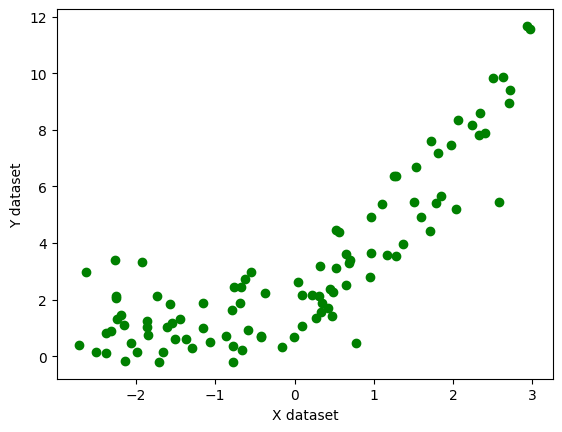

In [2]:
X = 6 * np.random.rand(100, 1) - 3
y =0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used- y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
## Lets implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [5]:
regression_1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

0.5958100826830652


Text(0, 0.5, 'Y')

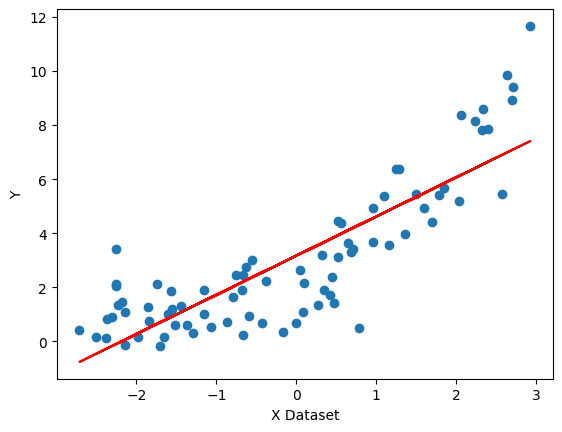

In [7]:
## Lets visualize this model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")


In [8]:
#LEts apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [9]:
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [10]:
X_train_poly

array([[ 1.00000000e+00,  1.59906115e+00,  2.55699657e+00],
       [ 1.00000000e+00, -1.06431423e+00,  1.13276477e+00],
       [ 1.00000000e+00, -3.74663839e-01,  1.40372992e-01],
       [ 1.00000000e+00, -2.25241933e+00,  5.07339285e+00],
       [ 1.00000000e+00, -1.70648815e+00,  2.91210182e+00],
       [ 1.00000000e+00,  9.94487118e-02,  9.89004627e-03],
       [ 1.00000000e+00, -2.14627494e+00,  4.60649611e+00],
       [ 1.00000000e+00, -2.50530364e+00,  6.27654631e+00],
       [ 1.00000000e+00, -1.44029571e+00,  2.07445174e+00],
       [ 1.00000000e+00, -7.91415124e-01,  6.26337898e-01],
       [ 1.00000000e+00, -2.25314393e+00,  5.07665757e+00],
       [ 1.00000000e+00, -2.37403424e+00,  5.63603857e+00],
       [ 1.00000000e+00,  2.05807364e+00,  4.23566711e+00],
       [ 1.00000000e+00,  3.19198234e-01,  1.01887513e-01],
       [ 1.00000000e+00,  1.25126553e+00,  1.56566542e+00],
       [ 1.00000000e+00,  1.16139946e+00,  1.34884871e+00],
       [ 1.00000000e+00,  1.84280679e+00

In [11]:
X_test_poly

array([[ 1.        ,  1.52867574,  2.33684951],
       [ 1.        ,  1.7203345 ,  2.95955079],
       [ 1.        ,  0.22613615,  0.05113756],
       [ 1.        ,  0.33436143,  0.11179756],
       [ 1.        , -0.7734272 ,  0.59818963],
       [ 1.        ,  2.49978043,  6.24890219],
       [ 1.        ,  1.27874436,  1.63518715],
       [ 1.        ,  1.81357412,  3.2890511 ],
       [ 1.        ,  0.48396379,  0.23422095],
       [ 1.        , -2.62581379,  6.89489804],
       [ 1.        ,  0.64808322,  0.42001186],
       [ 1.        , -2.05865451,  4.23805841],
       [ 1.        , -0.77368   ,  0.59858074],
       [ 1.        , -1.8614747 ,  3.46508807],
       [ 1.        ,  1.9694422 ,  3.87870257],
       [ 1.        ,  0.31286032,  0.09788158],
       [ 1.        , -1.91901853,  3.68263214],
       [ 1.        , -0.42825   ,  0.18339807],
       [ 1.        ,  0.95197915,  0.9062643 ],
       [ 1.        ,  2.97374221,  8.84314274]])

In [12]:

from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.873898341653731


In [13]:
print(regression.coef_)

[[0.         1.42259764 0.44373076]]


In [14]:
print(regression.intercept_)

[2.04141072]


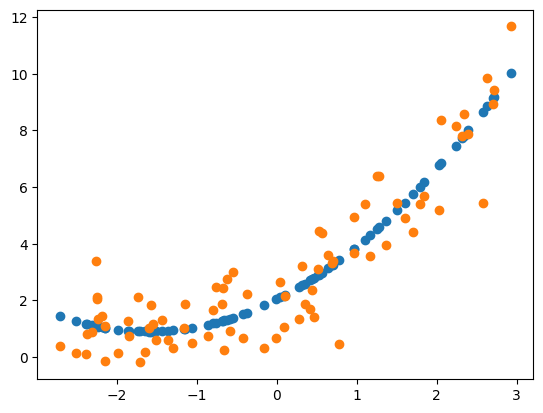

In [15]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [16]:
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [17]:
X_train_poly

array([[ 1.00000000e+00,  1.59906115e+00,  2.55699657e+00,
         4.08879387e+00],
       [ 1.00000000e+00, -1.06431423e+00,  1.13276477e+00,
        -1.20561766e+00],
       [ 1.00000000e+00, -3.74663839e-01,  1.40372992e-01,
        -5.25926843e-02],
       [ 1.00000000e+00, -2.25241933e+00,  5.07339285e+00,
        -1.14274081e+01],
       [ 1.00000000e+00, -1.70648815e+00,  2.91210182e+00,
        -4.96946727e+00],
       [ 1.00000000e+00,  9.94487118e-02,  9.89004627e-03,
         9.83552361e-04],
       [ 1.00000000e+00, -2.14627494e+00,  4.60649611e+00,
        -9.88680716e+00],
       [ 1.00000000e+00, -2.50530364e+00,  6.27654631e+00,
        -1.57246543e+01],
       [ 1.00000000e+00, -1.44029571e+00,  2.07445174e+00,
        -2.98782395e+00],
       [ 1.00000000e+00, -7.91415124e-01,  6.26337898e-01,
        -4.95693285e-01],
       [ 1.00000000e+00, -2.25314393e+00,  5.07665757e+00,
        -1.14384402e+01],
       [ 1.00000000e+00, -2.37403424e+00,  5.63603857e+00,
      

In [18]:

from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.869245946293709


In [19]:
#3 Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

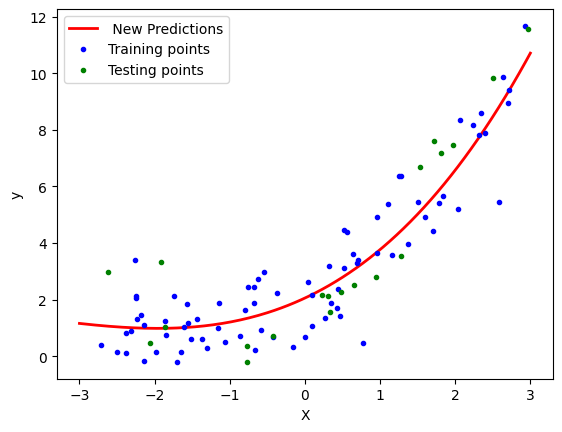

In [20]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline Concepts 

In [21]:
from sklearn.pipeline import Pipeline

In [22]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()
    

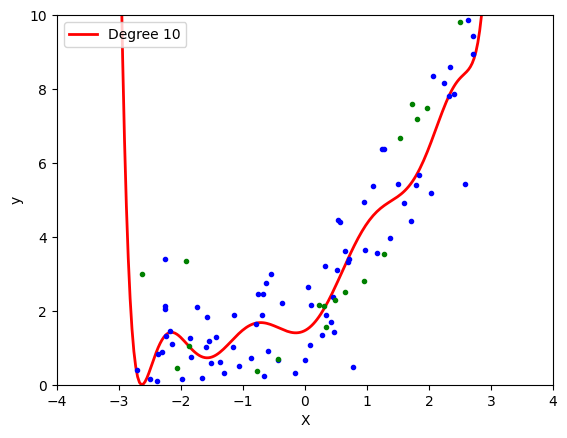

In [28]:
poly_regression(10)